## EDA  — Mindtune sessions

This notebook performs quick exploratory data analysis (EDA) on the merged dataset:

- `all_sessions_eeg_with_markers.csv`



In [1]:
# If running on Colab (or a fresh environment), install dependencies.
# Locally, you can skip this cell if you already have them installed.

%pip -q install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = os.environ.get("DATA_PATH", "all_sessions_eeg_with_markers.csv")
print("Loading:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.head()

Loading: all_sessions_eeg_with_markers.csv


,source_folder,source_session_path,timestamp_ms,session_id,participant_id,signal_quality,attention,meditation,delta,theta,...,ev_tech_issue,annotator_confidence,marker_emotion,marker_emotion_confidence,marker_ev_speaking_active,marker_ev_question_active,marker_ev_scolded_active,marker_ev_praised_active,marker_ev_qna_active,marker_ev_tech_issue_active
0,sessions,sessions/0054,1774857972940,0054,P0054,51,77,97,393129,7261,...,0,2,NaN,NaN,0,0,0,0,0,0
1,sessions,sessions/0054,1774857973920,0054,P0054,51,77,97,139346,70478,...,0,2,NaN,NaN,0,0,0,0,0,0
2,sessions,sessions/0054,1774857976914,0054,P0054,25,77,97,433,148,...,0,2,NaN,NaN,0,0,0,0,0,0
3,sessions,sessions/0054,1774857977910,0054,P0054,25,77,97,765093,36482,...,1,2,NaN,NaN,0,0,0,0,0,1
4,sessions,sessions/0054,1774857978884,0054,P0054,51,77,97,2010865,230926,...,1,2,NaN,NaN,0,0,0,0,0,1


In [6]:
# Basic shape + schema
print("rows, cols:", df.shape)
display(df.dtypes.to_frame("dtype").head(40))

# Quick missingness overview (top 30)
na = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
display(na.head(30).to_frame("% missing"))

# Sanity check IDs
print("unique sessions:", df["session_id"].nunique())
print("unique participants:", df["participant_id"].nunique())
print("source_folders:", df["source_folder"].value_counts().to_dict())

rows, cols: (11945, 36)


,dtype
source_folder,str
source_session_path,str
timestamp_ms,int64
session_id,str
participant_id,str
signal_quality,int64
attention,int64
meditation,int64
delta,int64
theta,int64


,% missing
marker_emotion_confidence,21.72
marker_emotion,21.72
source_folder,0.00
ev_tech_issue,0.00
emo_unknown,0.00
ev_speaking,0.00
ev_question,0.00
ev_scolded,0.00
ev_praised,0.00
ev_qna,0.00


unique sessions: 65
unique participants: 54
source_folders: {'sessions 6': 3645, 'sessions 5': 3019, 'sessions 2': 3005, 'sessions': 2276}


In [7]:
# Time + ordering helpers
# (timestamp_ms is epoch milliseconds)
df["timestamp_ms"] = pd.to_numeric(df["timestamp_ms"], errors="coerce")
df = df.dropna(subset=["timestamp_ms"]).copy()
df["timestamp"] = pd.to_datetime(df["timestamp_ms"], unit="ms", utc=True)

# Sort within each session
_df = df.sort_values(["session_id", "timestamp_ms"]).reset_index(drop=True)
_df[["session_id","participant_id","timestamp","signal_quality"]].head()

,session_id,participant_id,timestamp,signal_quality
0,00061,P0061,2026-03-30 08:00:27.762000+00:00,25
1,00061,P0061,2026-03-30 08:00:27.762000+00:00,25
2,00061,P0061,2026-03-30 08:00:29.754000+00:00,51
3,00061,P0061,2026-03-30 08:00:29.754000+00:00,51
4,00061,P0061,2026-03-30 08:00:32.742000+00:00,51


emo cols: ['emo_calm', 'emo_stressed', 'emo_delighted', 'emo_angry', 'emo_unknown']
event cols: ['ev_speaking', 'ev_question', 'ev_scolded', 'ev_praised', 'ev_qna', 'ev_tech_issue']
marker event active cols: ['marker_ev_speaking_active', 'marker_ev_question_active', 'marker_ev_scolded_active', 'marker_ev_praised_active', 'marker_ev_qna_active', 'marker_ev_tech_issue_active']


,count
emo_stressed,6186
emo_unknown,3612
emo_calm,2097
emo_delighted,33
emo_angry,17


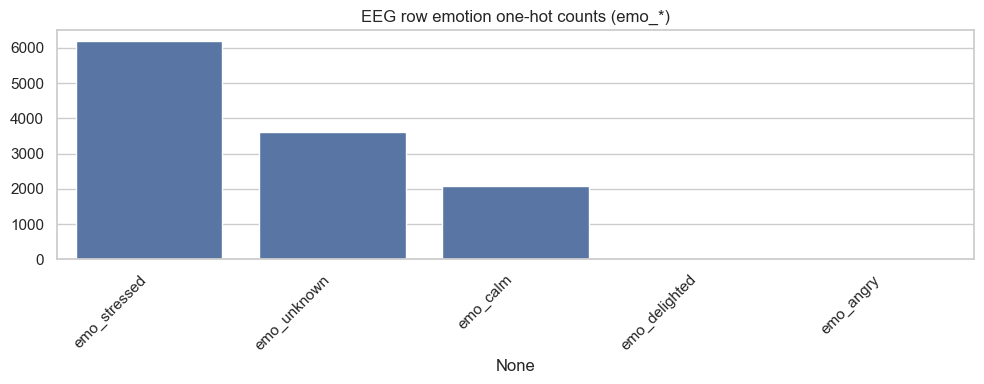

,rows
marker_emotion,
stressed,6186
(none yet),2595
calm,2097
unknown,1017
delighted,33
angry,17


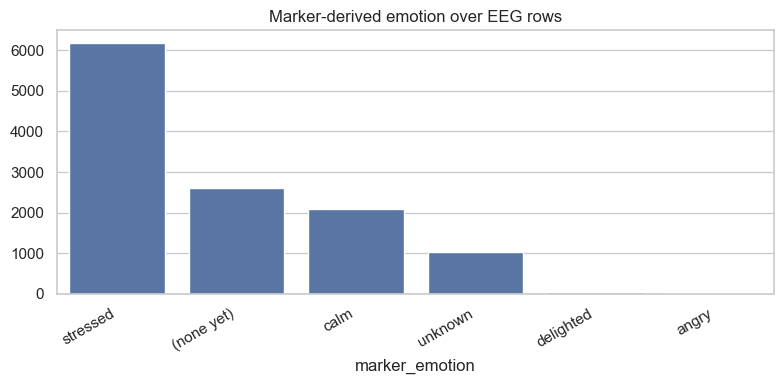

In [8]:
# Label columns that already exist in eeg_rows
emo_cols = [c for c in _df.columns if c.startswith("emo_")]
ev_cols = [c for c in _df.columns if c.startswith("ev_")]
marker_ev_active_cols = [c for c in _df.columns if c.startswith("marker_ev_") and c.endswith("_active")]

print("emo cols:", emo_cols)
print("event cols:", ev_cols)
print("marker event active cols:", marker_ev_active_cols)

# Distribution of one-hot emotion labels (from eeg_rows)
if emo_cols:
    emo_counts = _df[emo_cols].sum().sort_values(ascending=False)
    display(emo_counts.to_frame("count"))

    plt.figure(figsize=(10, 4))
    sns.barplot(x=emo_counts.index, y=emo_counts.values)
    plt.xticks(rotation=45, ha="right")
    plt.title("EEG row emotion one-hot counts (emo_*)")
    plt.tight_layout()
    plt.show()

# Distribution of marker-derived emotion (carried forward)
if "marker_emotion" in _df.columns:
    vc = _df["marker_emotion"].fillna("").replace({"": "(none yet)"}).value_counts()
    display(vc.to_frame("rows"))

    plt.figure(figsize=(8, 4))
    sns.barplot(x=vc.index, y=vc.values)
    plt.xticks(rotation=30, ha="right")
    plt.title("Marker-derived emotion over EEG rows")
    plt.tight_layout()
    plt.show()

,count,mean,std,min,25%,50%,75%,max
signal_quality,11945.0,31.506404,47.499323,0.0,0.0,26.0,51.0,200.0
attention,11945.0,31.393219,29.219557,0.0,0.0,34.0,54.0,100.0
meditation,11945.0,33.028631,29.415616,0.0,0.0,37.0,56.0,100.0
delta,11945.0,848110.941733,637445.650067,0.0,347253.0,716095.0,1201200.0,4017698.0
theta,11945.0,315474.442193,390933.102807,0.0,64091.0,168828.0,406129.0,3346457.0
low_alpha,11945.0,103669.636501,171577.697943,0.0,14697.0,42497.0,118189.0,2896245.0
high_alpha,11945.0,98280.128757,163420.358306,0.0,13263.0,38633.0,112312.0,2523598.0
low_beta,11945.0,76780.774969,130779.308255,0.0,11097.0,31292.0,85572.0,1830033.0
high_beta,11945.0,67583.075262,113562.572626,0.0,9158.0,26593.0,77689.0,1582280.0
low_gamma,11945.0,43512.268732,85083.193658,0.0,4062.0,13323.0,45849.0,1232913.0


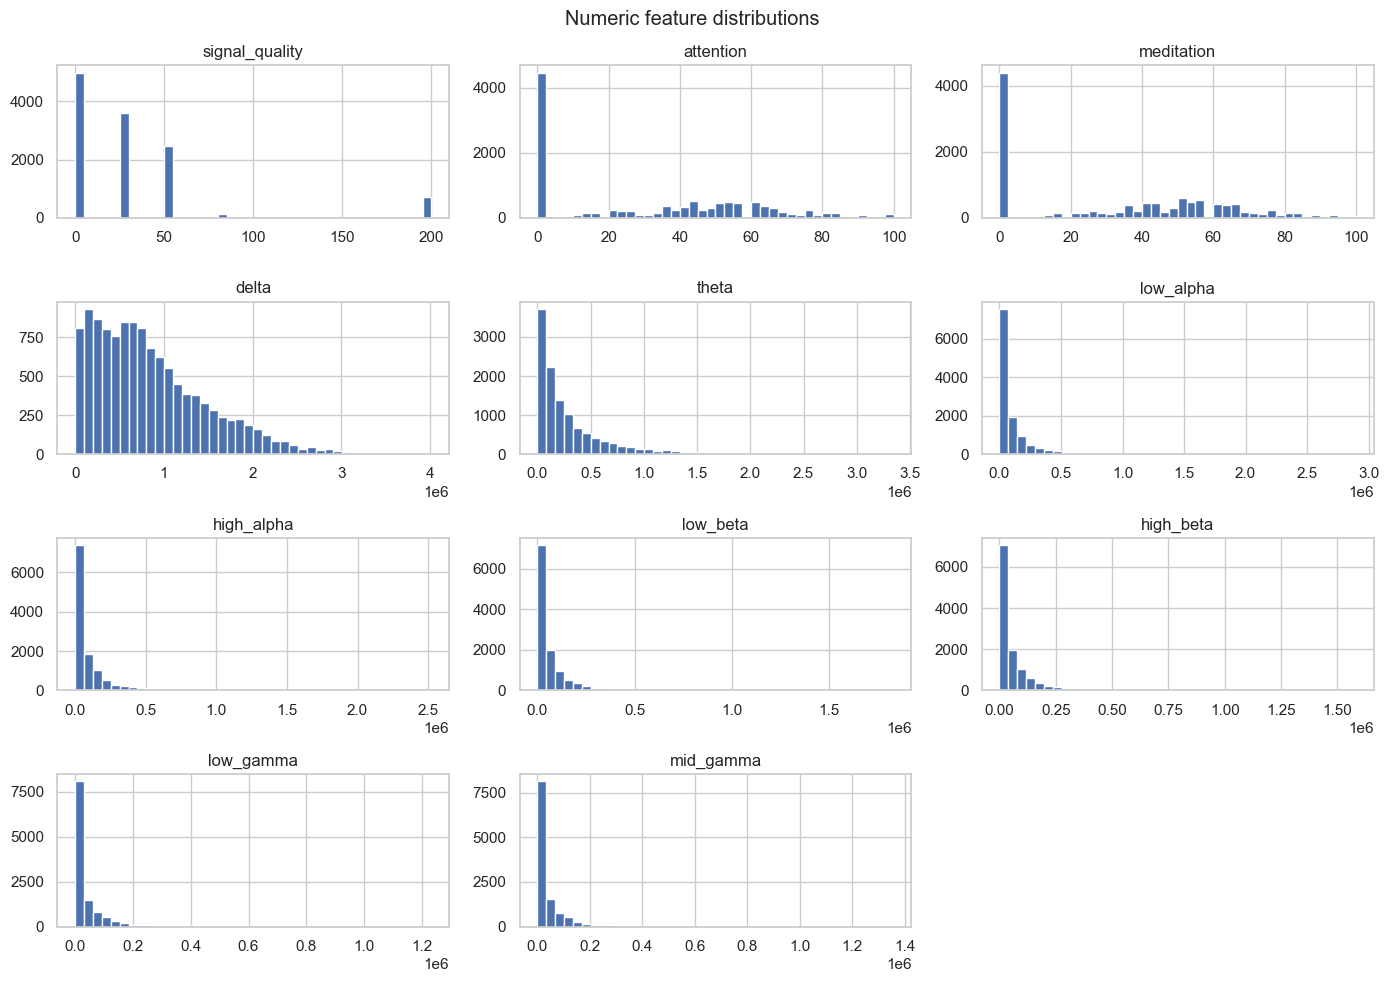

In [9]:
# Basic feature distributions
num_cols = [
    "signal_quality",
    "attention",
    "meditation",
    "delta",
    "theta",
    "low_alpha",
    "high_alpha",
    "low_beta",
    "high_beta",
    "low_gamma",
    "mid_gamma",
]
num_cols = [c for c in num_cols if c in _df.columns]

display(_df[num_cols].describe().T)

# Histograms
_df[num_cols].hist(bins=40, figsize=(14, 10))
plt.suptitle("Numeric feature distributions")
plt.tight_layout()
plt.show()

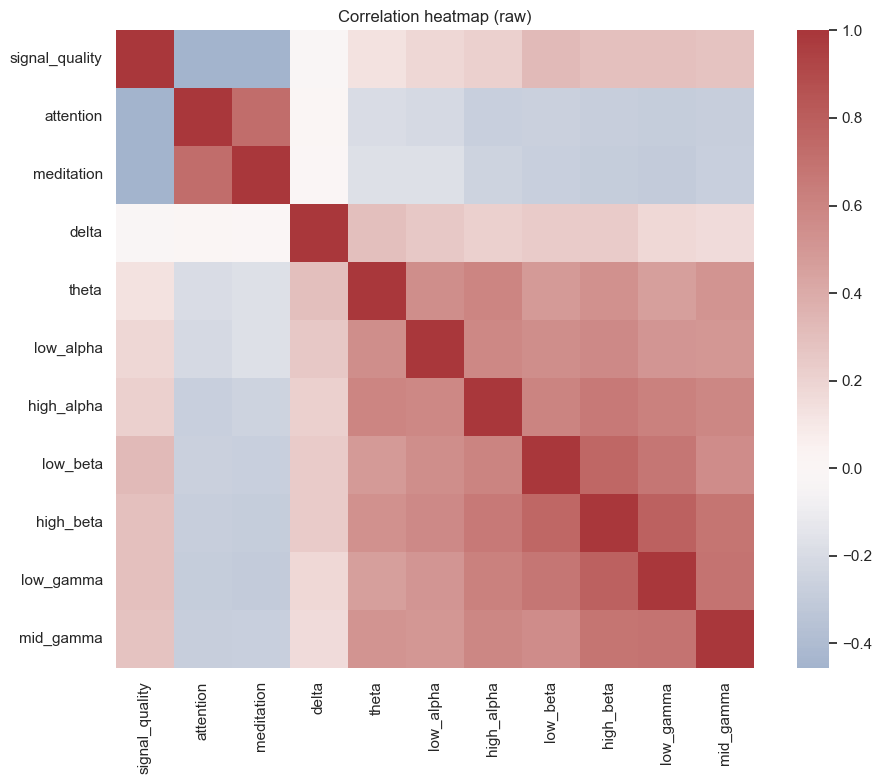

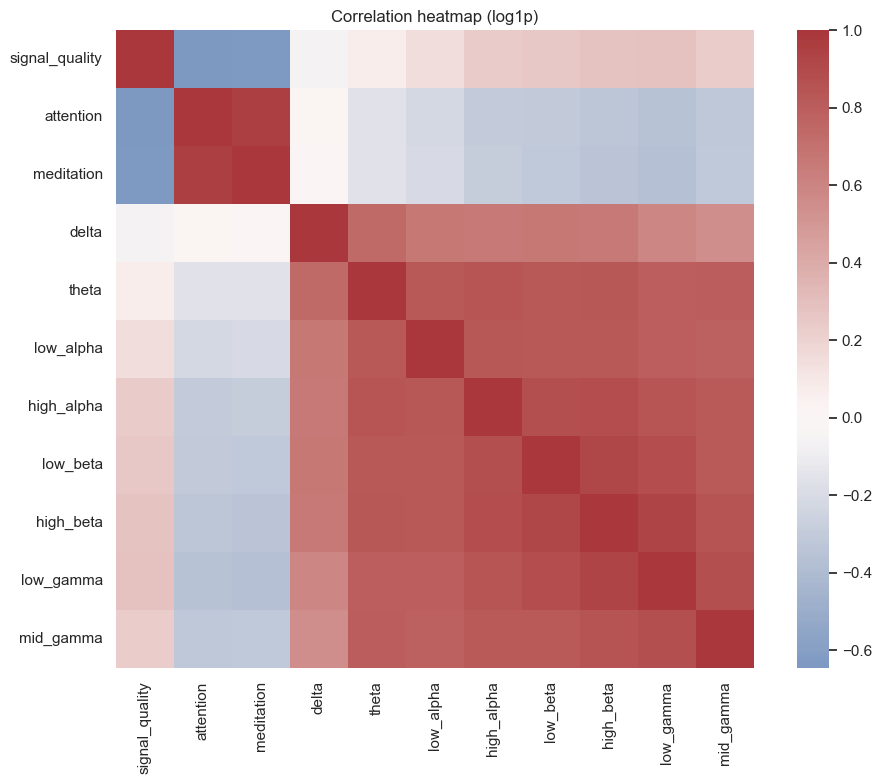

In [10]:
# Correlations (numeric features)
# Note: band powers can be heavy-tailed; consider log1p for nicer structure.

corr_cols = [c for c in num_cols if c in _df.columns]
X = _df[corr_cols].apply(pd.to_numeric, errors="coerce")

corr = X.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="vlag", center=0, square=True)
plt.title("Correlation heatmap (raw)")
plt.tight_layout()
plt.show()

corr_log = np.log1p(X).corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_log, cmap="vlag", center=0, square=True)
plt.title("Correlation heatmap (log1p)")
plt.tight_layout()
plt.show()

,% of time active
marker_ev_speaking_active,44.94
marker_ev_qna_active,40.28
marker_ev_question_active,33.57
marker_ev_tech_issue_active,9.23
marker_ev_scolded_active,8.11
marker_ev_praised_active,0.35


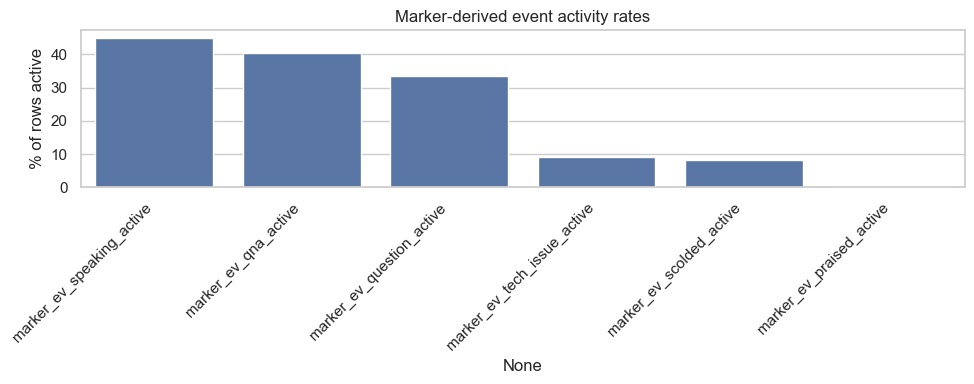

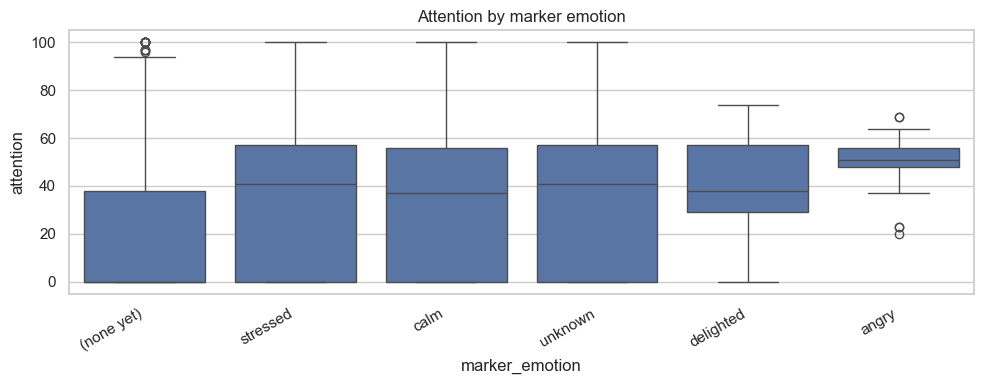

In [11]:
# Event activity analysis (marker-derived, carried forward)
if marker_ev_active_cols:
    active_rates = _df[marker_ev_active_cols].apply(pd.to_numeric, errors="coerce").fillna(0).mean().sort_values(ascending=False)
    display((active_rates * 100).round(2).to_frame("% of time active"))

    plt.figure(figsize=(10, 4))
    sns.barplot(x=active_rates.index, y=(active_rates.values * 100))
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("% of rows active")
    plt.title("Marker-derived event activity rates")
    plt.tight_layout()
    plt.show()

# Optional: compare attention/meditation by marker_emotion
if "marker_emotion" in _df.columns and "attention" in _df.columns:
    tmp = _df.copy()
    tmp["marker_emotion"] = tmp["marker_emotion"].fillna("").replace({"": "(none yet)"})
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=tmp, x="marker_emotion", y="attention")
    plt.xticks(rotation=30, ha="right")
    plt.title("Attention by marker emotion")
    plt.tight_layout()
    plt.show()

## Model-ready export (clean columns + 3-class label)

This section creates a clean, modeling-friendly dataset from `all_sessions_eeg_with_markers.csv`:

- **Label**: `label_3class` (`stressed` / `calm` / `neutral`) derived from `emo_*` (same rule as `scripts/train_model.py`).
- **Dedup**: removes duplicated EEG rows per session/time.
- **Features**: uses relative band-power percentages + attention/meditation.
- **Exports**: writes `model_ready.csv` (and a stricter variant).


In [12]:
# 1) Build label_3class (stressed/calm/neutral)
# Same rule used in scripts/train_model.py for session_meta-style CSVs.

df2 = df.copy()

for c in ["emo_stressed", "emo_calm"]:
    if c in df2.columns:
        df2[c] = pd.to_numeric(df2[c], errors="coerce").fillna(0).astype(int)

# default neutral
label = np.array(["neutral"] * len(df2), dtype=object)
if "emo_calm" in df2.columns:
    label[df2["emo_calm"].values == 1] = "calm"
if "emo_stressed" in df2.columns:
    label[df2["emo_stressed"].values == 1] = "stressed"

df2["label_3class"] = label

display(df2["label_3class"].value_counts().to_frame("rows"))

,rows
label_3class,
stressed,6186
neutral,3662
calm,2097


In [13]:
# 2) Duplicate check + dedupe within each session
# We dedupe by (source_session_path, timestamp_ms) keeping the first row after sorting.

key_cols = ["source_session_path", "timestamp_ms"]

# Ensure timestamp_ms is numeric for stable sorting
_df2 = df2.copy()
_df2["timestamp_ms"] = pd.to_numeric(_df2["timestamp_ms"], errors="coerce")
_df2 = _df2.dropna(subset=["timestamp_ms"]).copy()

# Count duplicates
dup_mask = _df2.duplicated(subset=key_cols, keep=False)
print("duplicate rows (same session_path + timestamp_ms):", int(dup_mask.sum()))

# Dedupe (keep first)
_df2 = _df2.sort_values(["source_session_path", "timestamp_ms"]).drop_duplicates(subset=key_cols, keep="first")
print("after dedupe rows:", len(_df2))

duplicate rows (same session_path + timestamp_ms): 0
after dedupe rows: 11945


In [14]:
# 3) Compute relative band-power percentages (scale-invariant features)

bands = ["delta","theta","low_alpha","high_alpha","low_beta","high_beta","low_gamma","mid_gamma"]
bands = [b for b in bands if b in _df2.columns]

for b in bands:
    _df2[b] = pd.to_numeric(_df2[b], errors="coerce")

band_total = _df2[bands].sum(axis=1)
for b in bands:
    _df2[f"{b}_pct"] = np.where(band_total > 0, _df2[b] / band_total, 0.0)

# normalize attention/meditation to numeric (optional features)
for c in ["attention","meditation","signal_quality"]:
    if c in _df2.columns:
        _df2[c] = pd.to_numeric(_df2[c], errors="coerce")

_df2[["label_3class"] + [f"{b}_pct" for b in bands] + [c for c in ["attention","meditation"] if c in _df2.columns]].head()

,label_3class,delta_pct,theta_pct,low_alpha_pct,high_alpha_pct,low_beta_pct,high_beta_pct,low_gamma_pct,mid_gamma_pct,attention,meditation
2276,neutral,0.467078,0.265206,0.128533,0.050845,0.027790,0.034583,0.015305,0.010660,0,0
2277,neutral,0.413261,0.078050,0.037040,0.097766,0.183268,0.087125,0.078961,0.024529,0,0
2278,neutral,0.174512,0.213347,0.030989,0.137245,0.081974,0.111543,0.090289,0.160102,0,0
2279,neutral,0.490884,0.045275,0.103336,0.058793,0.161836,0.110594,0.021518,0.007764,0,0
2280,neutral,0.530692,0.134205,0.043207,0.047427,0.117048,0.087426,0.025402,0.014592,0,0


In [15]:
# 4) Drop unnecessary columns and export
# We keep only: IDs (for splitting), label, and model features.

id_cols = [c for c in ["source_folder","source_session_path","session_id","participant_id","timestamp_ms"] if c in _df2.columns]
feature_cols = [f"{b}_pct" for b in bands] + [c for c in ["attention","meditation","signal_quality"] if c in _df2.columns]

keep_cols = id_cols + ["label_3class"] + feature_cols
model_df = _df2[keep_cols].copy()

print("model_df shape:", model_df.shape)
display(model_df.head())

# Export 1: standard (keeps neutral)
out1 = "model_ready.csv"
model_df.to_csv(out1, index=False)
print("wrote", out1)

# Export 2: strict (drops rows where original label is unknown OR marker_emotion missing, if present)
strict = _df2.copy()
if "emo_unknown" in strict.columns:
    strict["emo_unknown"] = pd.to_numeric(strict["emo_unknown"], errors="coerce").fillna(0).astype(int)
    strict = strict[strict["emo_unknown"] != 1]
if "marker_emotion" in strict.columns:
    strict = strict[strict["marker_emotion"].notna()]

strict_df = strict[keep_cols].copy()
out2 = "model_ready_strict.csv"
strict_df.to_csv(out2, index=False)
print("wrote", out2, "shape:", strict_df.shape)

# Quick label counts
print("label counts (model_ready):")
print(model_df["label_3class"].value_counts())
print("label counts (strict):")
print(strict_df["label_3class"].value_counts())

model_df shape: (11945, 17)


,source_folder,source_session_path,session_id,participant_id,timestamp_ms,label_3class,delta_pct,theta_pct,low_alpha_pct,high_alpha_pct,low_beta_pct,high_beta_pct,low_gamma_pct,mid_gamma_pct,attention,meditation,signal_quality
2276,sessions 2,sessions 2/00061,00061,P0061,1774857627762,neutral,0.467078,0.265206,0.128533,0.050845,0.027790,0.034583,0.015305,0.010660,0,0,25
2277,sessions 2,sessions 2/00061,00061,P0061,1774857629754,neutral,0.413261,0.078050,0.037040,0.097766,0.183268,0.087125,0.078961,0.024529,0,0,51
2278,sessions 2,sessions 2/00061,00061,P0061,1774857632742,neutral,0.174512,0.213347,0.030989,0.137245,0.081974,0.111543,0.090289,0.160102,0,0,51
2279,sessions 2,sessions 2/00061,00061,P0061,1774857634832,neutral,0.490884,0.045275,0.103336,0.058793,0.161836,0.110594,0.021518,0.007764,0,0,51
2280,sessions 2,sessions 2/00061,00061,P0061,1774857635730,neutral,0.530692,0.134205,0.043207,0.047427,0.117048,0.087426,0.025402,0.014592,0,0,51


wrote model_ready.csv
wrote model_ready_strict.csv shape: (8333, 17)
label counts (model_ready):
label_3class
stressed    6186
neutral     3662
calm        2097
Name: count, dtype: int64
label counts (strict):
label_3class
stressed    6186
calm        2097
neutral       50
Name: count, dtype: int64


## Build a “best” training dataset (less noisy)

Goal: produce a cleaner dataset for 3-class prediction by:

- removing ambiguous / noisy labels
- filtering low signal quality
- aggregating into time windows (reduces per-row noise)
- evaluating after each change (macro-F1 + confusion matrix)


In [16]:
from typing import Dict, List, Tuple
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


def eval_cv(
    df_in: pd.DataFrame,
    *,
    feature_cols: List[str],
    label_col: str,
    group_col: str = "session_id",
    folds: int = 5,
    model: str = "logreg",
    seed: int = 42,
) -> Dict:
    df_in = df_in.dropna(subset=feature_cols + [label_col, group_col]).copy()
    X = df_in[feature_cols].to_numpy(dtype=float)
    y = df_in[label_col].astype(str).to_numpy()
    groups = df_in[group_col].astype(str).to_numpy()

    gkf = GroupKFold(n_splits=folds)

    accs, f1s = [], []
    cms = []

    for tr, te in gkf.split(X, y, groups):
        if model == "logreg":
            clf = Pipeline(
                [
                    ("scaler", StandardScaler()),
                    (
                        "clf",
                        LogisticRegression(
                            max_iter=5000,
                            class_weight="balanced",
                            random_state=seed,
                        ),
                    ),
                ]
            )
        elif model == "rf":
            clf = RandomForestClassifier(
                n_estimators=600,
                random_state=seed,
                class_weight="balanced",
                n_jobs=-1,
                max_depth=None,
                min_samples_leaf=2,
            )
        else:
            raise ValueError("model must be 'logreg' or 'rf'")

        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])
        accs.append(float(accuracy_score(y[te], pred)))
        f1s.append(float(f1_score(y[te], pred, average="macro", zero_division=0)))
        cms.append(confusion_matrix(y[te], pred, labels=["calm", "neutral", "stressed"]))

    cm_sum = sum(cms)
    return {
        "rows": int(len(df_in)),
        "acc_mean": float(np.mean(accs)),
        "acc_std": float(np.std(accs)),
        "macro_f1_mean": float(np.mean(f1s)),
        "macro_f1_std": float(np.std(f1s)),
        "cm_sum": cm_sum,
    }


def print_eval(name: str, out: Dict) -> None:
    print(name)
    print(f"rows: {out['rows']}")
    print(f"acc mean±std: {out['acc_mean']:.4f}±{out['acc_std']:.4f}")
    print(f"macro-F1 mean±std: {out['macro_f1_mean']:.4f}±{out['macro_f1_std']:.4f}")
    print("confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:")
    display(pd.DataFrame(out["cm_sum"], index=["calm","neutral","stressed"], columns=["calm","neutral","stressed"]))

In [17]:
# Step A: start from merged dataset, derive a 3-class label
base = df.copy()

# Derive label_3class from emo_* (same rule you’ve been using)
for c in ["emo_stressed", "emo_calm", "emo_unknown"]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce").fillna(0).astype(int)

label = np.array(["neutral"] * len(base), dtype=object)
label[base.get("emo_calm", 0).values == 1] = "calm"
label[base.get("emo_stressed", 0).values == 1] = "stressed"
base["label_3class"] = label

# Features: band % + attention/meditation + signal_quality + marker events
bands = ["delta","theta","low_alpha","high_alpha","low_beta","high_beta","low_gamma","mid_gamma"]
for b in bands:
    base[b] = pd.to_numeric(base[b], errors="coerce")

total = base[bands].sum(axis=1)
for b in bands:
    base[f"{b}_pct"] = np.where(total > 0, base[b] / total, 0.0)

for c in ["attention","meditation","signal_quality"]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce")

event_cols = sorted([c for c in base.columns if c.startswith("marker_ev_") and c.endswith("_active")])
for c in event_cols:
    base[c] = pd.to_numeric(base[c], errors="coerce").fillna(0).astype(int)

feature_cols = [f"{b}_pct" for b in bands] + [c for c in ["attention","meditation","signal_quality"] if c in base.columns] + event_cols

print("features:", len(feature_cols))
print("label counts:")
display(base["label_3class"].value_counts().to_frame("rows"))

features: 17
label counts:


,rows
label_3class,
stressed,6186
neutral,3662
calm,2097


In [18]:
# Step B: baseline evaluation (row-level)
# Use session_id grouping to avoid leakage across time within a session.

row_level = base.dropna(subset=["session_id", "timestamp_ms"]).copy()

out_logreg = eval_cv(row_level, feature_cols=feature_cols, label_col="label_3class", group_col="session_id", folds=5, model="logreg")
print_eval("Row-level (logreg)", out_logreg)

out_rf = eval_cv(row_level, feature_cols=feature_cols, label_col="label_3class", group_col="session_id", folds=5, model="rf")
print_eval("Row-level (rf)", out_rf)

Row-level (logreg)
rows: 11945
acc mean±std: 0.5074±0.0686
macro-F1 mean±std: 0.4650±0.0513
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,775,731,591
neutral,1057,1907,698
stressed,1748,1059,3379


Row-level (rf)
rows: 11945
acc mean±std: 0.5831±0.0637
macro-F1 mean±std: 0.4581±0.0571
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,173,1036,888
neutral,288,2314,1060
stressed,301,1407,4478


In [19]:
# Step C: reduce label noise
# 1) Drop emo_unknown rows (they’re a very noisy source of “neutral”)
# 2) Optionally drop rows before first marker emotion (marker_emotion missing)

clean = row_level.copy()

if "emo_unknown" in clean.columns:
    clean = clean[clean["emo_unknown"] != 1]

# Optional: keep only rows that are inside annotated emotion segments
# (uncomment if you want strict labels)
# if "marker_emotion" in clean.columns:
#     clean = clean[clean["marker_emotion"].notna()]

print("after dropping emo_unknown:")
display(clean["label_3class"].value_counts().to_frame("rows"))

out_logreg = eval_cv(clean, feature_cols=feature_cols, label_col="label_3class", group_col="session_id", folds=5, model="logreg")
print_eval("Row-level cleaned (drop emo_unknown) (logreg)", out_logreg)

out_rf = eval_cv(clean, feature_cols=feature_cols, label_col="label_3class", group_col="session_id", folds=5, model="rf")
print_eval("Row-level cleaned (drop emo_unknown) (rf)", out_rf)

after dropping emo_unknown:


,rows
label_3class,
stressed,6186
calm,2097
neutral,50


Row-level cleaned (drop emo_unknown) (logreg)
rows: 8333
acc mean±std: 0.5575±0.1006
macro-F1 mean±std: 0.3751±0.0784
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,1401,121,575
neutral,4,0,46
stressed,2116,825,3245


Row-level cleaned (drop emo_unknown) (rf)
rows: 8333
acc mean±std: 0.7519±0.0601
macro-F1 mean±std: 0.4400±0.0933
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,572,0,1525
neutral,14,0,36
stressed,491,1,5694


In [20]:
# Step D: filter low signal quality (try a couple cutoffs)
# NOTE: you must pick this based on your device; we’ll evaluate impact.

if "signal_quality" in clean.columns:
    for thr in [0, 25, 50]:
        tmp = clean[clean["signal_quality"] >= thr].copy()
        out = eval_cv(tmp, feature_cols=feature_cols, label_col="label_3class", group_col="session_id", folds=5, model="logreg")
        print_eval(f"Row-level + drop emo_unknown + signal_quality>={thr} (logreg)", out)
else:
    print("signal_quality not found in dataset")

Row-level + drop emo_unknown + signal_quality>=0 (logreg)
rows: 8333
acc mean±std: 0.5575±0.1006
macro-F1 mean±std: 0.3751±0.0784
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,1401,121,575
neutral,4,0,46
stressed,2116,825,3245


Row-level + drop emo_unknown + signal_quality>=25 (logreg)
rows: 4571
acc mean±std: 0.6394±0.0709
macro-F1 mean±std: 0.4197±0.0510
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,887,18,279
neutral,0,0,10
stressed,1073,268,2036


Row-level + drop emo_unknown + signal_quality>=50 (logreg)
rows: 1810
acc mean±std: 0.6260±0.0395
macro-F1 mean±std: 0.4482±0.1537
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,349,0,179
neutral,0,0,3
stressed,493,2,784


In [21]:
# Step E: windowing (this is usually the biggest improvement)
# We’ll build non-overlapping windows per session_id using timestamp_ms.
# Label per window = majority label; drop windows with no clear majority (optional).

WINDOW_MS = 5000  # try 2000 or 5000
MIN_SAMPLES_PER_WINDOW = 3
MAJORITY_FRAC = 0.6  # require at least 60% of samples in the window to agree

wdf = clean.copy()
wdf["timestamp_ms"] = pd.to_numeric(wdf["timestamp_ms"], errors="coerce")
wdf = wdf.dropna(subset=["timestamp_ms"]).copy()

# Create a window id inside each session
wdf = wdf.sort_values(["session_id", "timestamp_ms"]).copy()
wdf["window_id"] = (wdf["timestamp_ms"] // WINDOW_MS).astype(int)

agg_cols = feature_cols

# Aggregate features by mean
feat_agg = wdf.groupby(["session_id", "window_id"], as_index=False)[agg_cols].mean()

# Aggregate label by majority vote
counts = (
    wdf.groupby(["session_id", "window_id", "label_3class"]).size().reset_index(name="n")
)

total_n = counts.groupby(["session_id", "window_id"], as_index=False)["n"].sum().rename(columns={"n": "n_total"})
counts = counts.merge(total_n, on=["session_id", "window_id"], how="left")
counts["frac"] = counts["n"] / counts["n_total"]

# Pick top label per window
counts = counts.sort_values(["session_id", "window_id", "n"], ascending=[True, True, False])
top = counts.drop_duplicates(["session_id", "window_id"], keep="first")

# Filter windows
top = top[(top["n_total"] >= MIN_SAMPLES_PER_WINDOW) & (top["frac"] >= MAJORITY_FRAC)].copy()

win = feat_agg.merge(top[["session_id", "window_id", "label_3class", "n_total", "frac"]], on=["session_id", "window_id"], how="inner")

print("windowed rows:", len(win))
display(win["label_3class"].value_counts().to_frame("windows"))

out = eval_cv(win, feature_cols=feature_cols, label_col="label_3class", group_col="session_id", folds=5, model="logreg")
print_eval(f"Windowed {WINDOW_MS}ms (logreg)", out)

out = eval_cv(win, feature_cols=feature_cols, label_col="label_3class", group_col="session_id", folds=5, model="rf")
print_eval(f"Windowed {WINDOW_MS}ms (rf)", out)

# Export the best dataset candidate
win.to_csv("model_ready_windowed.csv", index=False)
print("wrote model_ready_windowed.csv")

windowed rows: 1436


,windows
label_3class,
stressed,1060
calm,368
neutral,8


Windowed 5000ms (logreg)
rows: 1436
acc mean±std: 0.6169±0.1121
macro-F1 mean±std: 0.4013±0.0709
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,266,4,98
neutral,0,0,8
stressed,408,32,620


Windowed 5000ms (rf)
rows: 1436
acc mean±std: 0.7430±0.0481
macro-F1 mean±std: 0.5305±0.1299
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,110,0,258
neutral,4,0,4
stressed,103,0,957


wrote model_ready_windowed.csv


In [22]:
# Step F: Train final model on the chosen dataset and save
# Pick one: `win` (windowed) or `clean` (row-level cleaned)

FINAL_DF = win  # change to `clean` if you want row-level

# Train final model (rf or logreg)
MODEL_TYPE = "logreg"  # or "rf"

# Fit on ALL rows (for deployment)
X = FINAL_DF[feature_cols].to_numpy(dtype=float)
y = FINAL_DF["label_3class"].astype(str).to_numpy()

if MODEL_TYPE == "logreg":
    final_model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    )
elif MODEL_TYPE == "rf":
    final_model = RandomForestClassifier(
        n_estimators=800,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        min_samples_leaf=2,
    )
else:
    raise ValueError("MODEL_TYPE must be logreg or rf")

final_model.fit(X, y)

import joblib

bundle = {
    "model": final_model,
    "feature_cols": feature_cols,
    "label_col": "label_3class",
    "window_ms": WINDOW_MS if "win" in globals() else None,
    "notes": "Trained from eda_collab.ipynb dataset builder",
}
joblib.dump(bundle, "best_model_from_notebook.joblib")
print("Saved best_model_from_notebook.joblib")

Saved best_model_from_notebook.joblib


## Recommended pipeline (based on your results)

Your results show:

- Dropping `emo_unknown` makes **neutral almost vanish** → hurts 3-class learning.
- **Windowing** helps a lot (macro-F1 went up to ~0.53 with RF), but neutral still vanished because of the strict drop.

So the best next dataset is:

1) Keep all rows (including `emo_unknown`), map them to **neutral**, *then*
2) Window (2–5s) + majority vote label
3) Optionally require a majority threshold (e.g., 0.6) to reduce noise


In [23]:
# Build a better 3-class windowed dataset WITHOUT dropping emo_unknown
# (emo_unknown contributes to neutral, which is required for a real 3-class model)

WINDOW_MS = 5000  # try 2000, 5000
MIN_SAMPLES_PER_WINDOW = 3
MAJORITY_FRAC = 0.6

wdf2 = row_level.copy()  # <- row_level includes all rows
wdf2["timestamp_ms"] = pd.to_numeric(wdf2["timestamp_ms"], errors="coerce")
wdf2 = wdf2.dropna(subset=["timestamp_ms", "session_id"]).copy()

# window id per session
wdf2 = wdf2.sort_values(["session_id", "timestamp_ms"]).copy()
wdf2["window_id"] = (wdf2["timestamp_ms"] // WINDOW_MS).astype(int)

# mean features
feat_agg2 = wdf2.groupby(["session_id", "window_id"], as_index=False)[feature_cols].mean()

# majority-vote label
counts2 = wdf2.groupby(["session_id", "window_id", "label_3class"]).size().reset_index(name="n")
total2 = counts2.groupby(["session_id", "window_id"], as_index=False)["n"].sum().rename(columns={"n": "n_total"})
counts2 = counts2.merge(total2, on=["session_id", "window_id"], how="left")
counts2["frac"] = counts2["n"] / counts2["n_total"]
counts2 = counts2.sort_values(["session_id", "window_id", "n"], ascending=[True, True, False])
top2 = counts2.drop_duplicates(["session_id", "window_id"], keep="first")

# keep only sufficiently populated & confident windows
# (this is where we reduce noise, without deleting the whole neutral class)
top2 = top2[(top2["n_total"] >= MIN_SAMPLES_PER_WINDOW) & (top2["frac"] >= MAJORITY_FRAC)].copy()

win2 = feat_agg2.merge(
    top2[["session_id", "window_id", "label_3class", "n_total", "frac"]],
    on=["session_id", "window_id"],
    how="inner",
)

print("windowed rows:", len(win2))
display(win2["label_3class"].value_counts().to_frame("windows"))

out = eval_cv(win2, feature_cols=feature_cols, label_col="label_3class", group_col="session_id", folds=5, model="logreg")
print_eval(f"Windowed(all rows) {WINDOW_MS}ms (logreg)", out)

out = eval_cv(win2, feature_cols=feature_cols, label_col="label_3class", group_col="session_id", folds=5, model="rf")
print_eval(f"Windowed(all rows) {WINDOW_MS}ms (rf)", out)

win2.to_csv("model_ready_windowed_3class.csv", index=False)
print("wrote model_ready_windowed_3class.csv")

windowed rows: 2112


,windows
label_3class,
stressed,1063
neutral,682
calm,367


Windowed(all rows) 5000ms (logreg)
rows: 2112
acc mean±std: 0.4910±0.0317
macro-F1 mean±std: 0.4350±0.0496
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,115,140,112
neutral,230,302,150
stressed,267,176,620


Windowed(all rows) 5000ms (rf)
rows: 2112
acc mean±std: 0.5951±0.0465
macro-F1 mean±std: 0.4781±0.0388
confusion sum (rows=true, cols=pred) [calm, neutral, stressed]:


,calm,neutral,stressed
calm,42,150,175
neutral,62,420,200
stressed,65,203,795


wrote model_ready_windowed_3class.csv


### What to remove / ignore now

Based on the observed results, you can ignore/remove from your *training dataset*:

- Raw `delta/theta/...` (keep only `*_pct`)
- `source_folder`, `source_session_path`, `participant_id`, `timestamp_ms` (keep only for analysis/splitting; exclude from features)
- `emo_*` columns once `label_3class` is created
- `marker_emotion*` unless you’re using marker-based labels

And you should avoid a “strict” dataset that drops `emo_unknown` **if your goal is 3 classes**, because it collapses the neutral class.
